In [3]:
import os
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_dinamica_poblacional_txt(folder: str, fig_out: str) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:

    def load_txt(path: str) -> pd.DataFrame:
        df = pd.read_csv(path, sep=';')
        req = ['time', 'HS', 'HM', 'HPC', 'MS', 'MC', 'MPC']
        missing = [c for c in req if c not in df.columns]
        if missing:
            raise ValueError(f"Faltan columnas en {path}: {missing}")
        return df[req].copy()

    def nanmean_ci95(mat: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """
        mat: shape (n_runs, T) con NaN para padding.
        Devuelve (mean, lo, hi) con IC95% por tiempo.
        """
        m = np.nanmean(mat, axis=0)
        # Si hay una sola corrida en algún tiempo, std muestral no está definido.
        # Usamos ddof=1 cuando haya n>1, y 0 en caso contrario (se maneja con 'n').
        s = np.nanstd(mat, axis=0, ddof=1)
        n = np.sum(~np.isnan(mat), axis=0).astype(float)
        se = np.where(n > 1, s / np.sqrt(n), 0.0)
        ci = 1.96 * se
        return m, m - ci, m + ci

    def stack_runs(series_list: List[np.ndarray]) -> np.ndarray:
        """Apila listas 1D con distinto largo en una matriz (n_runs, T_max) con NaN padding."""
        T = max(len(s) for s in series_list)
        M = np.full((len(series_list), T), np.nan, dtype=float)
        for i, s in enumerate(series_list):
            M[i, :len(s)] = s
        return M

    def aggregate_txt(files: List[str]) -> Dict[str, Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
        """
        Devuelve por cada estado (HS, HM, HPC, MS, MC, MPC) una tupla (x, mean, lo, hi).
        """
        states = ['HS', 'HM', 'HPC', 'MS', 'MC', 'MPC']
        per_state = {k: [] for k in states}
        xs = []

        for f in files:
            df = load_txt(f)
            xs.append(df['time'].to_numpy())
            for k in states:
                per_state[k].append(df[k].to_numpy(dtype=float))

        # Eje de tiempo unificado: 0..Tmax usando padding por NaN
        T = max(x.size for x in xs) if xs else 0
        x = np.arange(T)

        out = {}
        for k, lst in per_state.items():
            if len(lst) == 0:
                out[k] = (x, np.array([]), np.array([]), np.array([]))
            else:
                M = stack_runs(lst)  # (n_runs, T)
                mean, lo, hi = nanmean_ci95(M)
                out[k] = (x, mean, lo, hi)
        return out

    def plot_ci(ax, x, mean, lo, hi, label):
        ax.plot(x, mean, label=label)
        ax.fill_between(x, lo, hi, alpha=0.2)

    # ---------- Recolección y orden de archivos ----------
    if not os.path.isdir(folder):
        raise FileNotFoundError(f"No existe la carpeta: {folder}")

    txt_files = [os.path.join(folder, f) for f in os.listdir(folder) if f.endswith(".txt")]

    # Ordenar por el número al final del nombre, si sigue *_<numero>.txt; si no, por nombre
    def _suffix_key(path: str) -> Tuple[int, str]:
        base = os.path.basename(path)
        try:
            # Toma el último bloque separado por '_' y remueve '.txt'
            return (int(base.split("_")[-1].replace(".txt","")), base)
        except Exception:
            return (10**9, base)  # manda los no-numéricos al final

    txt_files.sort(key=_suffix_key)

    if len(txt_files) == 0:
        raise FileNotFoundError(f"No se encontraron .txt en la carpeta: {folder}")

    # ---------- Agregación ----------
    agg = aggregate_txt(txt_files)

    # ---------- Gráficos ----------
    fig, (ax_h, ax_m) = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

    # Humanos
    for k in ['HS', 'HM', 'HPC']:
        x, mean, lo, hi = agg[k]
        plot_ci(ax_h, x, mean, lo, hi, k)
    ax_h.set_title("Humanos: HS / HM / HPC")
    ax_h.set_xlabel("time")
    ax_h.set_ylabel("count")
    ax_h.grid(True, alpha=0.3)
    ax_h.legend()

    # Mosquitos
    for k in ['MS', 'MC', 'MPC']:
        x, mean, lo, hi = agg[k]
        plot_ci(ax_m, x, mean, lo, hi, k)
    ax_m.set_title("Mosquitos: MS / MC / MPC")
    ax_m.set_xlabel("time")
    ax_m.grid(True, alpha=0.3)
    ax_m.legend()

    plt.tight_layout()
    plt.savefig(fig_out, dpi=400, bbox_inches="tight")
    plt.show(fig)
    plt.close(fig)

    return agg

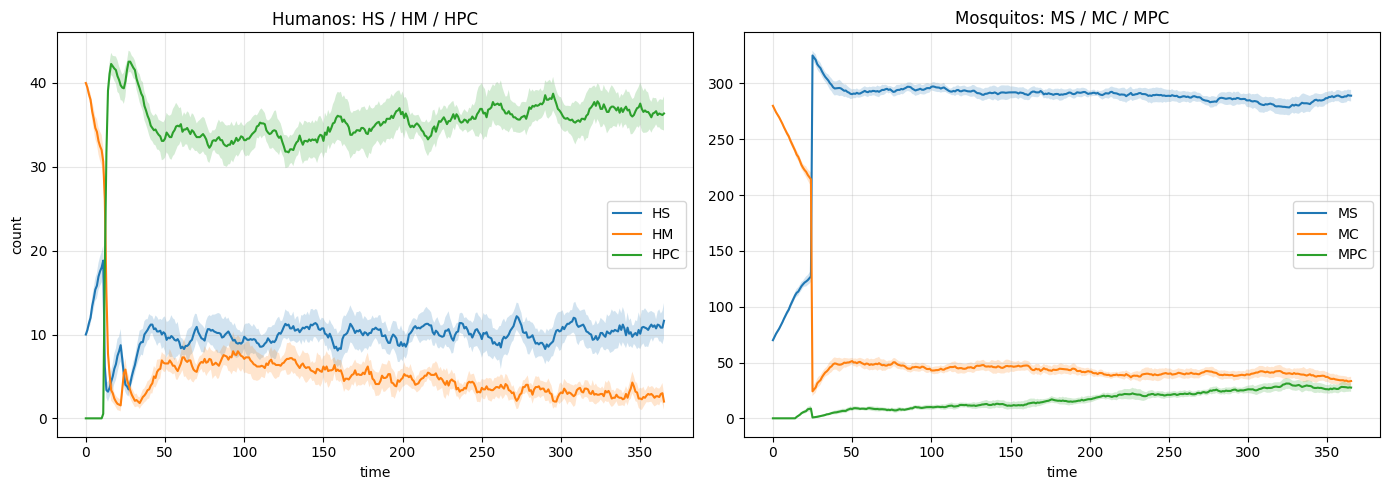

In [5]:
# plotear y guardar la figura
agg = plot_dinamica_poblacional_txt(folder="results/num_genomes_2_bitting_rate_4",
                                    fig_out="fig_1_num_genomes_2_bitting_rate_4")

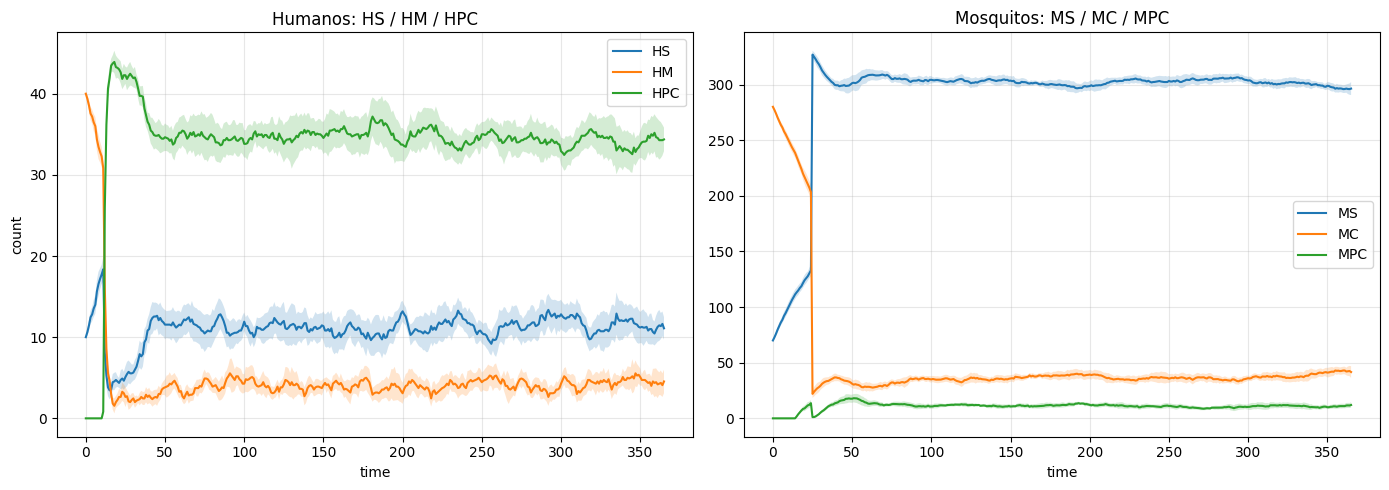

In [6]:
# plotear y guardar la figura
agg = plot_dinamica_poblacional_txt(folder="results/num_genomes_10_bitting_rate_4",
                                    fig_out="fig_1_num_genomes_10_bitting_rate_4")

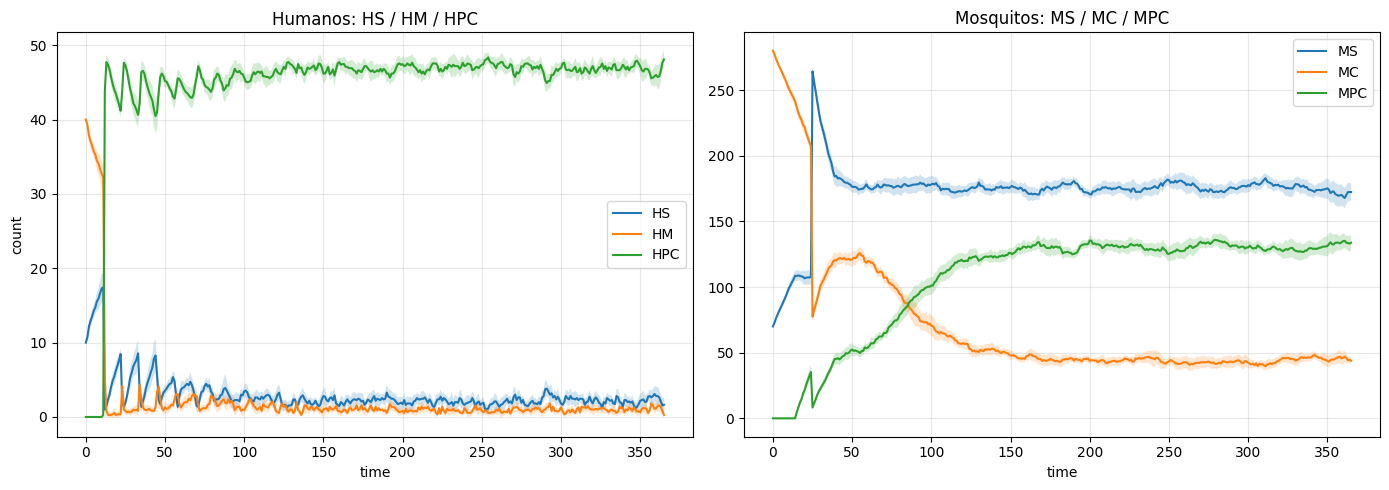

In [7]:
# plotear y guardar la figura
agg = plot_dinamica_poblacional_txt(folder="results/num_genomes_2_bitting_rate_40",
                                    fig_out="fig_1_num_genomes_2_bitting_rate_40")

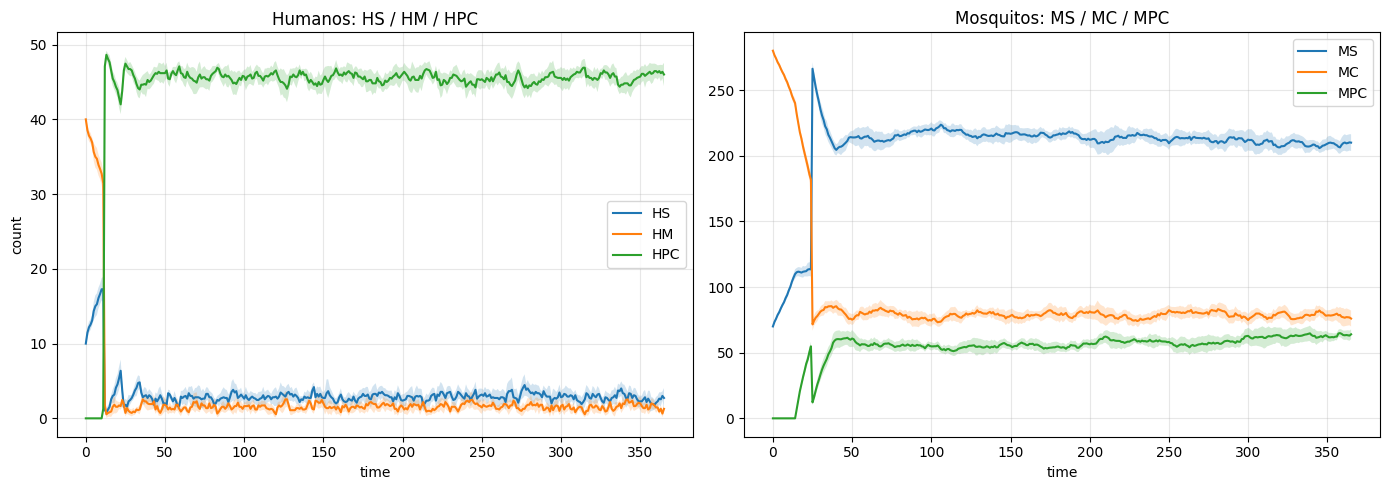

In [8]:
# plotear y guardar la figura
agg = plot_dinamica_poblacional_txt(folder="results/num_genomes_10_bitting_rate_40",
                                    fig_out="fig_1_num_genomes_10_bitting_rate_40")